# Predicting Corporate Bankruptcy: Traditional Machine Learning vs. Deep Learning

**Intro to Machine Learning — Summative Project**

## 1. Introduction

Corporate bankruptcy prediction is one of the oldest and most consequential problems in quantitative
finance. For a lender or a bank, the cost of failing to flag a company that later defaults (a *false
negative*) is far higher than the cost of over-cautiously flagging a healthy company (a *false positive*).
This asymmetry — and the fact that bankruptcies are *rare* — shapes every modelling decision in this
notebook.

We use the **Taiwan Economic Journal (TEJ) bankruptcy dataset**, which records **95 financial ratios** for
**6,819 listed companies** over 1999–2009, with a binary label `Bankrupt?`. Only **220 companies (3.23%)**
went bankrupt, making this a *severely imbalanced* classification problem. This realism is exactly what
makes it a good vehicle for demonstrating the difference between traditional machine learning
(scikit-learn) and deep learning (TensorFlow), and for showing why **accuracy is a misleading metric**
here.

### Objectives
1. Build a leakage-free preprocessing pipeline (winsorization, robust scaling, feature pruning).
2. Compare **traditional ML** (Logistic Regression, Random Forest, XGBoost, SVM) against **deep learning**
   models built with the TensorFlow **Sequential API**, **Functional API**, and **`tf.data`** input pipeline.
3. Treat the **class imbalance** explicitly, comparing class-weighting against SMOTE oversampling.
4. Use **ROC-AUC and PR-AUC as decision-driving diagnostics** that steer the training process, not just as
   end-of-notebook plots.
5. Perform critical **error analysis** centred on the costly false-negative case.

> **Dataset citation (IEEE):** D. Liang, C.-C. Lu, C.-F. Tsai, and G.-A. Shih, "Financial ratios and
> corporate governance indicators in bankruptcy prediction: A comprehensive study," *European Journal of
> Operational Research*, vol. 252, no. 2, pp. 561–572, 2016. Data: Taiwan Economic Journal, hosted on the
> UCI Machine Learning Repository / Kaggle.

> **Note on execution:** this notebook is authored to run on **Google Colab with a GPU runtime and Google
> Drive mounted**. A clean *Restart and run all* reproduces every result. Model weights are checkpointed to
> Drive **after every epoch** so training survives a Colab disconnect.


## 2. Environment Setup & Reproducibility

We install the few libraries Colab does not ship by default, mount Google Drive (for checkpoints), seed
every random source, and print library versions so the run is reproducible and auditable.

In [ ]:
# Install extras not pre-installed on Colab. (No-op / fast if already present.)
# Comment this out when running locally with these already installed.
!pip install -q imbalanced-learn keras-tuner shap xgboost

In [1]:
import os, random, json, warnings, datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
import sklearn

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

SEED = 42

def set_seeds(seed=SEED):
    # Seed every random source we rely on for reproducibility.
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seeds()
print("  GPU available:", bool(tf.config.list_physical_devices("GPU")))

Library versions
  numpy      : 2.0.2
  pandas     : 2.2.2
  scikit-learn: 1.6.1
  tensorflow : 2.20.0
  GPU available: True


In [2]:
# Mount Google Drive so checkpoints survive a Colab runtime disconnect.
# If not on Colab, fall back to a local directory.
try:
    from google.colab import drive
    drive.mount("/content/drive")
    BASE_DIR = "/content/drive/MyDrive/bankruptcy_summative"
    IN_COLAB = True
except Exception:
    BASE_DIR = "./bankruptcy_summative"
    IN_COLAB = False

CKPT_DIR = os.path.join(BASE_DIR, "checkpoints")
os.makedirs(CKPT_DIR, exist_ok=True)
print("Running on Colab:", IN_COLAB)
print("Artifacts directory:", BASE_DIR)

Mounted at /content/drive
Running on Colab: True
Artifacts directory: /content/drive/MyDrive/bankruptcy_summative


In [3]:
# --- Locate the dataset -------------------------------------------------------
# On Colab, upload data.csv to the BASE_DIR on Drive, OR use files.upload().
# Locally, point DATA_PATH at the file directly.
CANDIDATES = [
    os.path.join(BASE_DIR, "data.csv"),
    "/content/data.csv",
    "data.csv",
    "intro _to _ml/data.csv",
]
DATA_PATH = next((p for p in CANDIDATES if os.path.exists(p)), None)

if DATA_PATH is None and IN_COLAB:
    from google.colab import files
    print("Upload data.csv ...")
    up = files.upload()
    DATA_PATH = list(up.keys())[0]

assert DATA_PATH is not None, "Could not find data.csv - set DATA_PATH manually."
print("Using dataset at:", DATA_PATH)

Using dataset at: /content/data.csv


**Insight.** The setup cell pins our software stack and seeds `random`, `numpy`, and `tensorflow` so
that splits, model initialisation, and SMOTE are deterministic across runs. Mounting Drive gives us a
persistent location for per-epoch checkpoints — the foundation of the disconnect-resilient training we set
up in Section 7.

## 3. Load the Data & First Look

We load the CSV, inspect its shape and types, confirm the target distribution, and identify columns that
carry no information (a constant flag) — all before touching any modelling.

In [5]:
df = pd.read_csv("/content/data.csv",
)
df.columns = df.columns.str.strip()   # the raw headers have leading spaces
TARGET = "Bankrupt?"

print("Shape:", df.shape)
print("\nTarget distribution:")
counts = df[TARGET].value_counts()
print(counts)
print("\nPositive (bankrupt) rate: {:.2%}".format(df[TARGET].mean()))
df.head()

Shape: (6819, 96)

Target distribution:
Bankrupt?
0    6599
1     220
Name: count, dtype: int64

Positive (bankrupt) rate: 3.23%


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [7]:
# Data types and a check for missing values.
print("Missing values total:", int(df.isna().sum().sum()))
print("Non-target dtypes:", df.drop(columns=[TARGET]).dtypes.unique())

# Flag zero-variance / constant columns (e.g. 'Net Income Flag' is always 1).
nunique = df.nunique()
constant_cols = nunique[nunique <= 1].index.tolist()
binary_cols = nunique[nunique == 2].index.drop(TARGET, errors="ignore").tolist()
print("\nConstant columns:", constant_cols)
print("Binary flag columns:", binary_cols)

Missing values total: 0
Non-target dtypes: [dtype('float64') dtype('int64')]

Constant columns: ['Net Income Flag']
Binary flag columns: ['Liability-Assets Flag']


**Insight.** The dataset is complete (no missing values) and entirely numeric, so we avoid imputation
and categorical encoding. The headline fact is the **3.23% positive rate**: a naive classifier that always
predicts "not bankrupt" would score ~96.8% accuracy while catching *zero* bankruptcies. That is precisely
why the rest of this notebook reports **Recall, F1, and PR-AUC** rather than accuracy. We also confirm
`Net Income Flag` is constant — it will be dropped in preprocessing.

## 4. Exploratory Data Analysis

We explore the imbalance, the scale and skew of the features, and the redundancy among the 95 ratios. Each
finding directly motivates a preprocessing choice in Section 5.

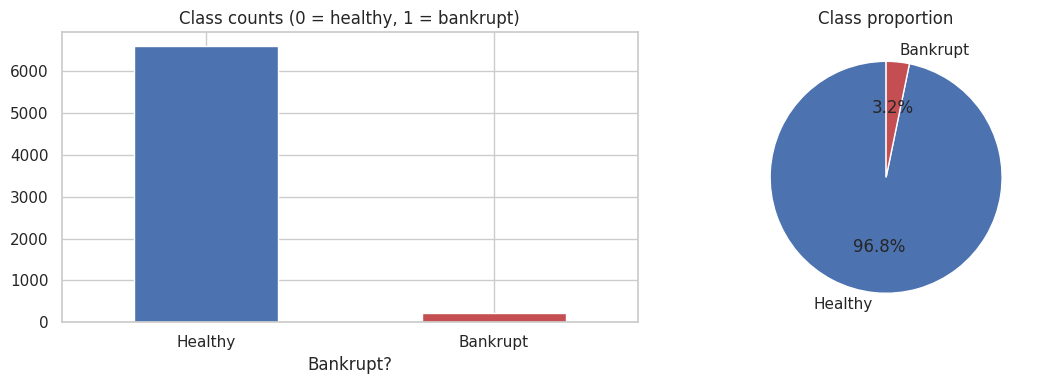

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
counts.plot(kind="bar", ax=ax[0], color=["#4c72b0", "#c44e52"])
ax[0].set_title("Class counts (0 = healthy, 1 = bankrupt)")
ax[0].set_xticklabels(["Healthy", "Bankrupt"], rotation=0)
ax[1].pie(counts, labels=["Healthy", "Bankrupt"], autopct="%1.1f%%",
          colors=["#4c72b0", "#c44e52"], startangle=90)
ax[1].set_title("Class proportion")
plt.tight_layout(); plt.show()

In [9]:
# Scale and skew: financial ratios live on wildly different scales with heavy tails.
desc = df.drop(columns=[TARGET]).describe().T[["min", "50%", "max", "std"]]
desc["skew"] = df.drop(columns=[TARGET]).skew()
print("Most extreme-scale features (by max value):")
print(desc.sort_values("max", ascending=False).head(8))
print("\nMost skewed features:")
print(desc.sort_values("skew", ascending=False).head(8))

Most extreme-scale features (by max value):
                                       min           50%           max  \
Current Asset Turnover Rate            0.0  1.987816e-04  1.000000e+10   
Cash Turnover Rate                     0.0  1.080000e+09  1.000000e+10   
Quick Asset Turnover Rate              0.0  2.247728e-04  1.000000e+10   
Fixed Assets Turnover Frequency        0.0  5.930942e-04  9.990000e+09   
Operating Expense Rate                 0.0  2.777589e-04  9.990000e+09   
Total Asset Growth Rate                0.0  6.400000e+09  9.990000e+09   
Inventory Turnover Rate (times)        0.0  7.646743e-04  9.990000e+09   
Research and development expense rate  0.0  5.090000e+08  9.980000e+09   

                                                std      skew  
Current Asset Turnover Rate            2.821161e+09  2.115956  
Cash Turnover Rate                     2.938623e+09  0.954117  
Quick Asset Turnover Rate              3.374944e+09  1.137353  
Fixed Assets Turnover Frequency  

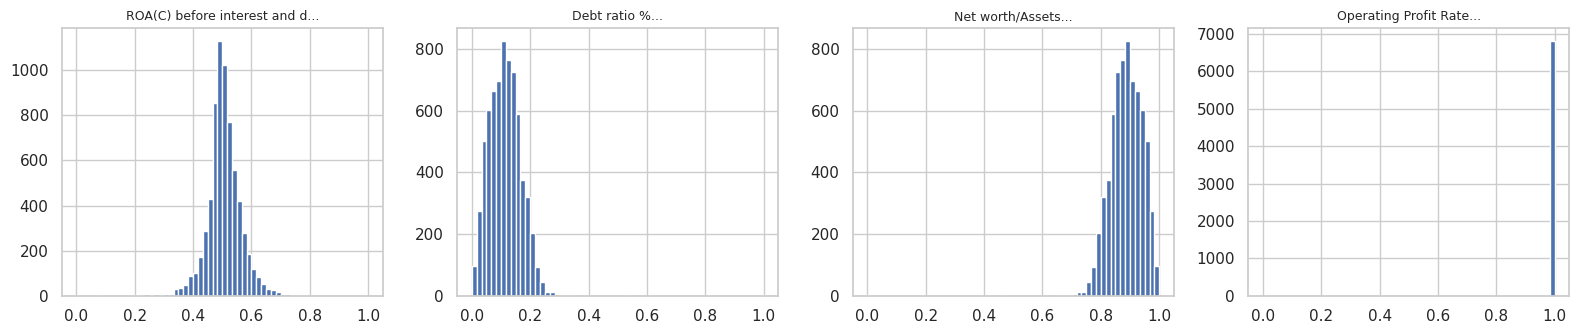

In [10]:
# Distribution of a few representative features (raw, before any transform).
sample_feats = [
    "ROA(C) before interest and depreciation before interest",
    "Debt ratio %",
    "Net worth/Assets",
    "Operating Profit Rate",
]
sample_feats = [f for f in sample_feats if f in df.columns][:4]
fig, axes = plt.subplots(1, len(sample_feats), figsize=(4*len(sample_feats), 3.5))
for ax, f in zip(np.atleast_1d(axes), sample_feats):
    ax.hist(df[f], bins=60, color="#4c72b0")
    ax.set_title(f[:28] + "...", fontsize=9)
plt.tight_layout(); plt.show()

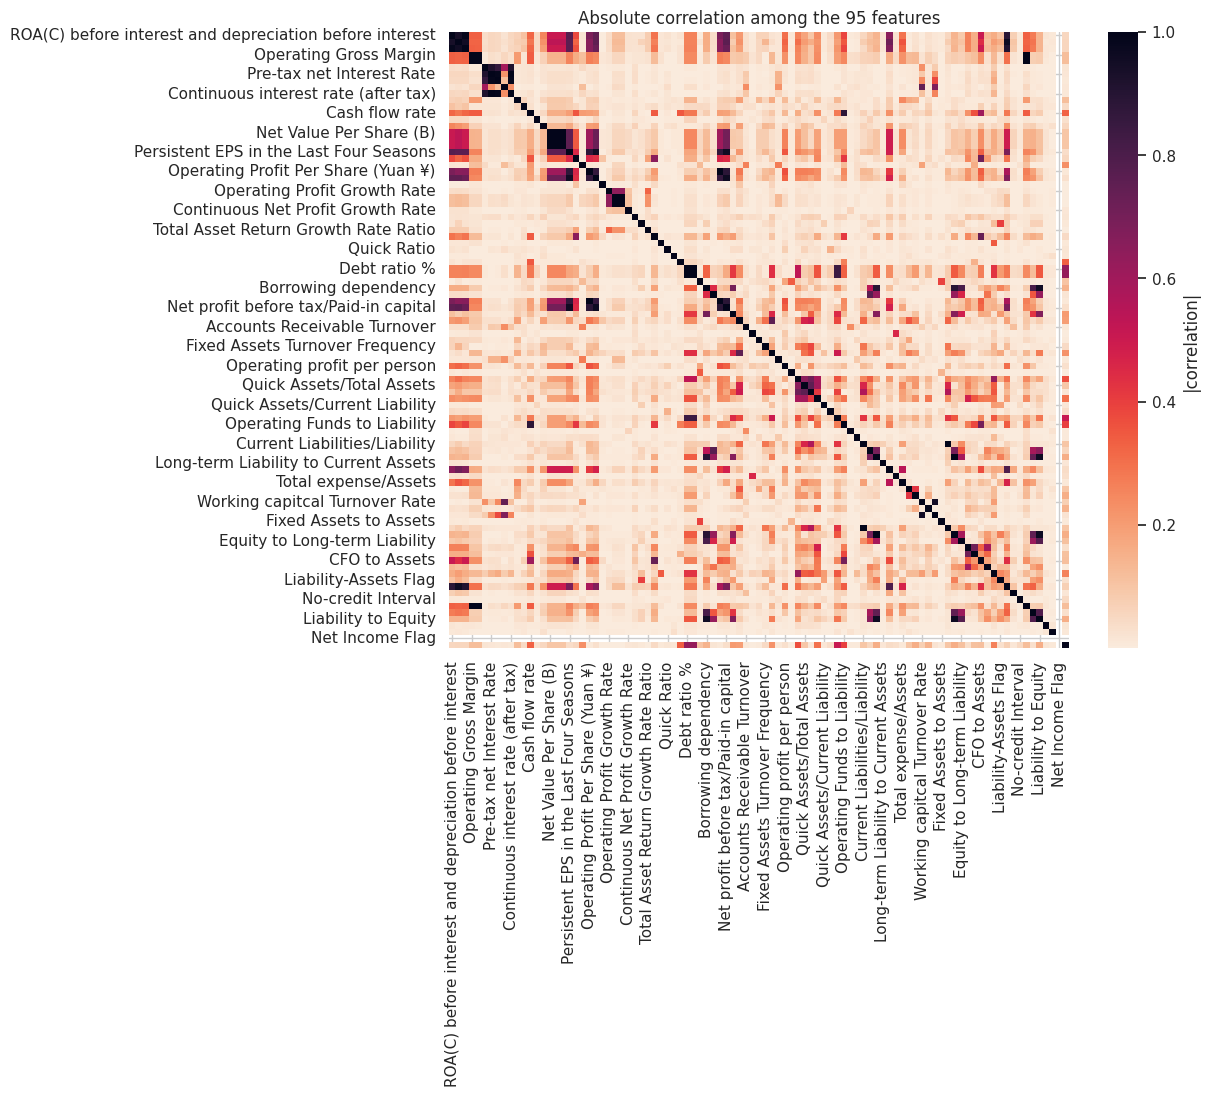

Number of features with a >0.9 correlated partner: 19


In [11]:
# Redundancy: many ratios are near-duplicates. Visualise the correlation structure.
corr = df.drop(columns=[TARGET]).corr().abs()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="rocket_r", cbar_kws={"label": "|correlation|"})
plt.title("Absolute correlation among the 95 features")
plt.show()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_pairs = [(c, upper.index[upper[c] > 0.9].tolist()) for c in upper.columns]
high_pairs = [(c, v) for c, v in high_pairs if v]
print("Number of features with a >0.9 correlated partner:", len(high_pairs))

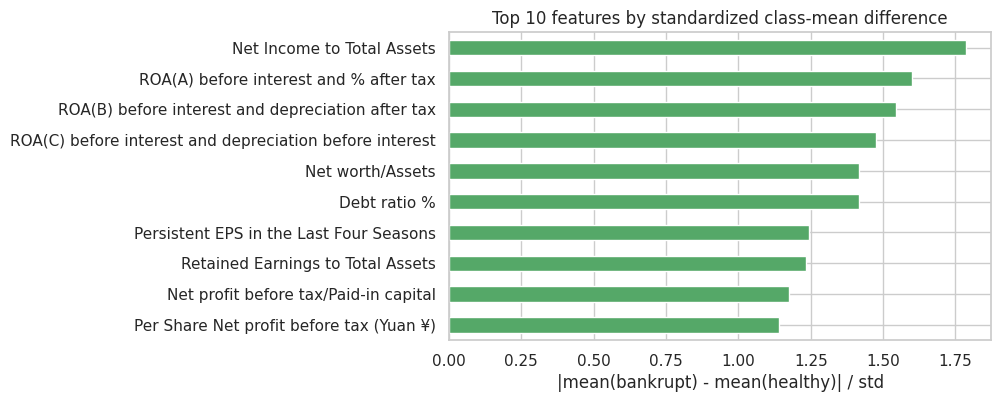

In [12]:
# Which features separate the two classes best (univariate signal)?
means = df.groupby(TARGET).mean().T
means["abs_diff"] = (means[1] - means[0]).abs()
means_norm = means["abs_diff"] / (df.drop(columns=[TARGET]).std() + 1e-9)
top_sep = means_norm.sort_values(ascending=False).head(10)
top_sep.plot(kind="barh", figsize=(7, 4), color="#55a868")
plt.gca().invert_yaxis()
plt.title("Top 10 features by standardized class-mean difference")
plt.xlabel("|mean(bankrupt) - mean(healthy)| / std")
plt.show()

**Insight.** Three EDA findings drive preprocessing. First, the features span many orders of magnitude
and are heavily right-skewed, with extreme outliers — this motivates **winsorizing at the 1st/99th
percentile** and using a **RobustScaler** (median/IQR) rather than standard scaling. Second, the correlation
heatmap shows large blocks of near-duplicate ratios; many features have a partner with |r| > 0.9, justifying
**correlation-based pruning**. Third, ratios such as debt ratio, net-worth/assets and persistent EPS show
the largest standardized separation between classes — an early hint at which features the models will lean
on, to be revisited in the error-analysis section.

## 5. Preprocessing Pipeline (leakage-free)

We apply the data preparation agreed up front. **Order matters for avoiding leakage:** we split first, then
fit every transformation (clip bounds, scaler, SMOTE) on the **training split only**.

1. **Stratified split** 60/20/20 into train/validation/test, preserving the 3.23% positive rate.
2. **Winsorize** each feature to its 1st–99th percentile (bounds from train).
3. **RobustScaler** (median/IQR), fit on train.
4. **Feature pruning**: drop the constant column and near-zero-variance features, then drop one of each
   |r| > 0.9 pair.
5. Prepare the **two imbalance variants** of the training set: class-weights and SMOTE.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import VarianceThreshold

X = df.drop(columns=[TARGET]).copy()
y = df[TARGET].astype(int).copy()

# 1) Stratified split: 60% train, 20% val, 20% test.
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

for name, yy in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"{name:5s}: n={len(yy):5d}  positives={yy.sum():3d}  rate={yy.mean():.2%}")

train: n= 4091  positives=132  rate=3.23%
val  : n= 1364  positives= 44  rate=3.23%
test : n= 1364  positives= 44  rate=3.23%


In [14]:
# 2) Winsorize: clip bounds fit on TRAIN ONLY, then applied to all splits.
lower = X_train.quantile(0.01)
upper = X_train.quantile(0.99)

def winsorize(frame):
    return frame.clip(lower=lower, upper=upper, axis=1)

X_train_w = winsorize(X_train)
X_val_w   = winsorize(X_val)
X_test_w  = winsorize(X_test)

# 3) RobustScaler fit on TRAIN ONLY.
scaler = RobustScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train_w), columns=X.columns, index=X_train.index)
X_val_s   = pd.DataFrame(scaler.transform(X_val_w),       columns=X.columns, index=X_val.index)
X_test_s  = pd.DataFrame(scaler.transform(X_test_w),      columns=X.columns, index=X_test.index)
print("Scaled feature ranges (train) look bounded:")
print(X_train_s.describe().T[["min", "50%", "max"]].head())

Scaled feature ranges (train) look bounded:
                                                         min  50%       max
ROA(C) before interest and depreciation before ... -2.960550  0.0  2.690575
ROA(A) before interest and % after tax             -4.231461  0.0  2.946374
ROA(B) before interest and depreciation after tax  -3.473649  0.0  2.691918
Operating Gross Margin                             -2.069847  0.0  3.352399
Realized Sales Gross Margin                        -2.053067  0.0  3.372563


In [15]:
# 4a) Drop constant / near-zero-variance features (variance computed on train).
vt = VarianceThreshold(threshold=1e-6)
vt.fit(X_train_s)
keep_var = X.columns[vt.get_support()]
print(f"Dropped {X.shape[1] - len(keep_var)} near-zero-variance feature(s): "
      f"{[c for c in X.columns if c not in keep_var]}")

X_train_s = X_train_s[keep_var]
X_val_s   = X_val_s[keep_var]
X_test_s  = X_test_s[keep_var]

Dropped 2 near-zero-variance feature(s): ['Liability-Assets Flag', 'Net Income Flag']


In [16]:
# 4b) Correlation pruning: drop one of each |r| > 0.9 pair (correlation from train).
corr_tr = X_train_s.corr().abs()
upper_tr = corr_tr.where(np.triu(np.ones(corr_tr.shape), k=1).astype(bool))
to_drop = [c for c in upper_tr.columns if any(upper_tr[c] > 0.90)]
print(f"Dropping {len(to_drop)} highly-correlated features (|r|>0.9).")

FEATURES = [c for c in X_train_s.columns if c not in to_drop]
X_train_s = X_train_s[FEATURES]
X_val_s   = X_val_s[FEATURES]
X_test_s  = X_test_s[FEATURES]
print("Final feature count:", len(FEATURES))

Dropping 23 highly-correlated features (|r|>0.9).
Final feature count: 70


In [17]:
# 5) Imbalance variants of the TRAINING set only.
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE

# (a) class weights
cw = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train)
CLASS_WEIGHT = {0: cw[0], 1: cw[1]}
print("Class weights:", {k: round(v, 2) for k, v in CLASS_WEIGHT.items()})

# (b) SMOTE-resampled training set (fit on train only)
smote = SMOTE(random_state=SEED)
X_train_smote, y_train_smote = smote.fit_resample(X_train_s, y_train)
print("SMOTE training distribution:", np.bincount(y_train_smote))

# Numpy views used throughout.
Xtr, Xva, Xte = X_train_s.values, X_val_s.values, X_test_s.values
ytr, yva, yte = y_train.values, y_val.values, y_test.values
Xtr_sm, ytr_sm = X_train_smote.values, y_train_smote.values
INPUT_DIM = Xtr.shape[1]

Class weights: {0: np.float64(0.52), 1: np.float64(15.5)}
SMOTE training distribution: [3959 3959]


**Insight.** The split preserves the 3.23% rate in every fold, so validation and test estimates are not
optimistic. Because clip bounds, the scaler, and SMOTE are all fit on the training split only, there is **no
information leakage** from validation/test into the model. Pruning removes the constant flag and the
redundant ratio blocks seen in the heatmap, leaving a compact, de-correlated feature set that benefits the
linear model and SVM in particular. We now hold two training variants — class-weighted and SMOTE — which we
compare head-to-head.

### Shared evaluation helpers

To compare ML and DL **fairly**, every model is scored through the same functions: identical metrics,
identical curves. This also gives us the ROC/PR machinery we will use *during* training, not just at the
end.

In [18]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve, f1_score,
                             precision_score, recall_score, accuracy_score)

RESULTS = []   # collects one row per (model, variant) for the final table

def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "accuracy":  accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall":    recall_score(y_true, y_pred, zero_division=0),
        "f1":        f1_score(y_true, y_pred, zero_division=0),
        "roc_auc":   roc_auc_score(y_true, y_prob),
        "pr_auc":    average_precision_score(y_true, y_prob),
    }

def evaluate_model(name, variant, y_true, y_prob, threshold=0.5, record=True, show=True):
    # Score a model, optionally plot the confusion matrix, and record the row.
    m = compute_metrics(y_true, y_prob, threshold)
    if record:
        RESULTS.append({"model": name, "variant": variant, **m})
    if show:
        y_pred = (y_prob >= threshold).astype(int)
        print(f"=== {name} [{variant}] (threshold={threshold:.2f}) ===")
        print(classification_report(y_true, y_pred, target_names=["healthy", "bankrupt"],
                                     zero_division=0))
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(4, 3.2))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=["healthy", "bankrupt"], yticklabels=["healthy", "bankrupt"])
        plt.title(f"{name} [{variant}]  PR-AUC={m['pr_auc']:.3f}")
        plt.ylabel("True"); plt.xlabel("Predicted"); plt.show()
    return m

def plot_roc_pr(curves, title=""):
    # curves: list of (label, y_true, y_prob). Plots ROC and PR side by side.
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
    for label, yt, yp in curves:
        fpr, tpr, _ = roc_curve(yt, yp)
        ax[0].plot(fpr, tpr, label=f"{label} (AUC={roc_auc_score(yt, yp):.3f})")
        prec, rec, _ = precision_recall_curve(yt, yp)
        ax[1].plot(rec, prec, label=f"{label} (AP={average_precision_score(yt, yp):.3f})")
    ax[0].plot([0, 1], [0, 1], "k--", lw=1)
    ax[0].set(xlabel="False Positive Rate", ylabel="True Positive Rate", title=f"ROC — {title}")
    base = yt.mean()
    ax[1].axhline(base, ls="--", c="k", lw=1, label=f"baseline={base:.3f}")
    ax[1].set(xlabel="Recall", ylabel="Precision", title=f"Precision-Recall — {title}")
    ax[0].legend(fontsize=8); ax[1].legend(fontsize=8); plt.tight_layout(); plt.show()

## 6. Traditional Machine Learning (scikit-learn)

We train four classifiers spanning linear, kernel, and tree-ensemble families. For each, we run a small
hyperparameter search **scored on PR-AUC** (`average_precision`) with stratified cross-validation — never on
accuracy. **ROC/PR-AUC is the decision variable**: for every model we train both imbalance variants
(class-weight and SMOTE) and *keep the one with the higher validation PR-AUC*.

In [19]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def tune(estimator, param_dist, Xt, yt, n_iter=15):
    search = RandomizedSearchCV(estimator, param_dist, n_iter=n_iter, scoring="average_precision",
                                cv=cv, random_state=SEED, n_jobs=-1, refit=True)
    search.fit(Xt, yt)
    return search.best_estimator_, search.best_params_, search.best_score_

In [21]:
# Define the four model families and their search spaces.
MODEL_SPACE = {
    "LogisticRegression": (
        LogisticRegression(max_iter=2000, solver="liblinear"),
        {"C": np.logspace(-3, 2, 10), "penalty": ["l1", "l2"]},
    ),
    "RandomForest": (
        RandomForestClassifier(random_state=SEED, n_jobs=-1),
        {"n_estimators": [200, 400, 600], "max_depth": [None, 6, 10, 16],
         "min_samples_leaf": [1, 2, 5], "max_features": ["sqrt", "log2"]},
    ),
    "XGBoost": (
        XGBClassifier(random_state=SEED, eval_metric="aucpr", tree_method="hist", n_jobs=-1),
        {"n_estimators": [200, 400], "max_depth": [3, 5, 7],
         "learning_rate": [0.03, 0.1, 0.3], "subsample": [0.7, 1.0],
         "colsample_bytree": [0.7, 1.0]},
    ),
    "SVM-RBF": (
        SVC(kernel="rbf", probability=True, random_state=SEED),
        {"C": np.logspace(-1, 2, 6), "gamma": ["scale", "auto", 0.01, 0.1]},
    ),
}

def with_weighting(name, est):
    # Return an estimator configured for class-weighting (variant a).
    if name == "XGBoost":
        return est.set_params(scale_pos_weight=(ytr == 0).sum() / (ytr == 1).sum())
    return est.set_params(class_weight="balanced")

In [22]:
# For each family, tune on BOTH imbalance variants and pick the higher validation PR-AUC.
ml_best = {}        # name -> (estimator, variant, val_prob)
ml_decision_log = []

for name, (est, space) in MODEL_SPACE.items():
    set_seeds()
    # Variant A: class weights on the original (imbalanced) training set.
    est_a, p_a, cvscore_a = tune(with_weighting(name, est.__class__(**est.get_params())), space, Xtr, ytr)
    prob_a = est_a.predict_proba(Xva)[:, 1]
    pr_a = average_precision_score(yva, prob_a)

    # Variant B: SMOTE-resampled training set (no class weights).
    est_b, p_b, cvscore_b = tune(est.__class__(**est.get_params()), space, Xtr_sm, ytr_sm)
    prob_b = est_b.predict_proba(Xva)[:, 1]
    pr_b = average_precision_score(yva, prob_b)

    if pr_a >= pr_b:
        ml_best[name] = (est_a, "class-weight", prob_a)
        winner, win_pr, los_pr = "class-weight", pr_a, pr_b
    else:
        ml_best[name] = (est_b, "SMOTE", prob_b)
        winner, win_pr, los_pr = "SMOTE", pr_b, pr_a
    ml_decision_log.append({"model": name, "winner": winner,
                            "val_PR_AUC_class_weight": round(pr_a, 4),
                            "val_PR_AUC_SMOTE": round(pr_b, 4),
                            "delta": round(win_pr - los_pr, 4)})
    print(f"{name:18s} -> kept {winner:11s} "
          f"(val PR-AUC: cw={pr_a:.3f} vs smote={pr_b:.3f})")

pd.DataFrame(ml_decision_log)

LogisticRegression -> kept class-weight (val PR-AUC: cw=0.397 vs smote=0.374)
RandomForest       -> kept class-weight (val PR-AUC: cw=0.492 vs smote=0.383)
XGBoost            -> kept SMOTE       (val PR-AUC: cw=0.422 vs smote=0.465)
SVM-RBF            -> kept class-weight (val PR-AUC: cw=0.119 vs smote=0.113)


,model,winner,val_PR_AUC_class_weight,val_PR_AUC_SMOTE,delta
0,LogisticRegression,class-weight,0.3974,0.3743,0.0231
1,RandomForest,class-weight,0.4916,0.3828,0.1088
2,XGBoost,SMOTE,0.4225,0.4646,0.0421
3,SVM-RBF,class-weight,0.1188,0.1130,0.0057


**Insight — ROC/PR-AUC as the decision variable.** The table above is an explicit *decision log*: for
each family we did **not** pick the imbalance strategy by intuition but by **validation PR-AUC**, keeping the
higher and recording the margin (`delta`). This is the first place AUC steers the pipeline rather than merely
describing it. Tuning was scored on `average_precision` (PR-AUC) because, under 3% prevalence, the precision-
recall curve reflects minority-class performance far better than ROC or accuracy.

=== LogisticRegression [class-weight] (threshold=0.50) ===
              precision    recall  f1-score   support

     healthy       0.99      0.89      0.94      1320
    bankrupt       0.20      0.84      0.33        44

    accuracy                           0.89      1364
   macro avg       0.60      0.87      0.63      1364
weighted avg       0.97      0.89      0.92      1364



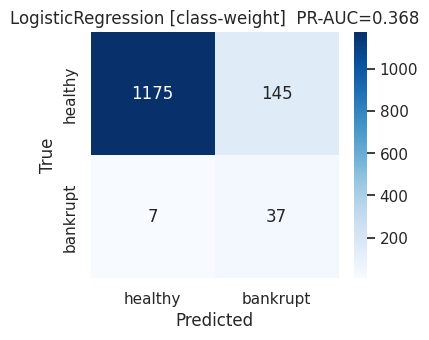

=== RandomForest [class-weight] (threshold=0.50) ===
              precision    recall  f1-score   support

     healthy       0.98      0.98      0.98      1320
    bankrupt       0.42      0.39      0.40        44

    accuracy                           0.96      1364
   macro avg       0.70      0.68      0.69      1364
weighted avg       0.96      0.96      0.96      1364



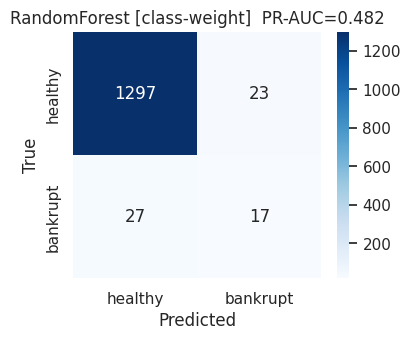

=== XGBoost [SMOTE] (threshold=0.50) ===
              precision    recall  f1-score   support

     healthy       0.98      0.98      0.98      1320
    bankrupt       0.48      0.45      0.47        44

    accuracy                           0.97      1364
   macro avg       0.73      0.72      0.72      1364
weighted avg       0.97      0.97      0.97      1364



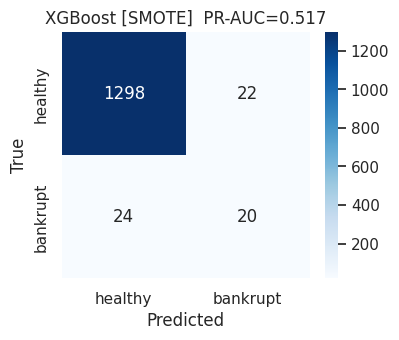

=== SVM-RBF [class-weight] (threshold=0.50) ===
              precision    recall  f1-score   support

     healthy       0.97      1.00      0.98      1320
    bankrupt       0.00      0.00      0.00        44

    accuracy                           0.97      1364
   macro avg       0.48      0.50      0.49      1364
weighted avg       0.94      0.97      0.95      1364



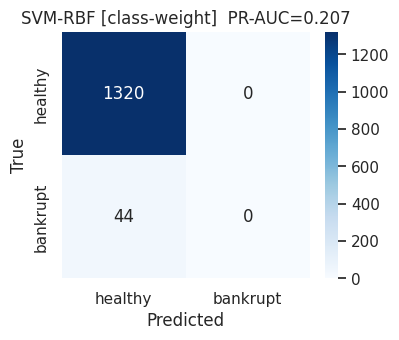

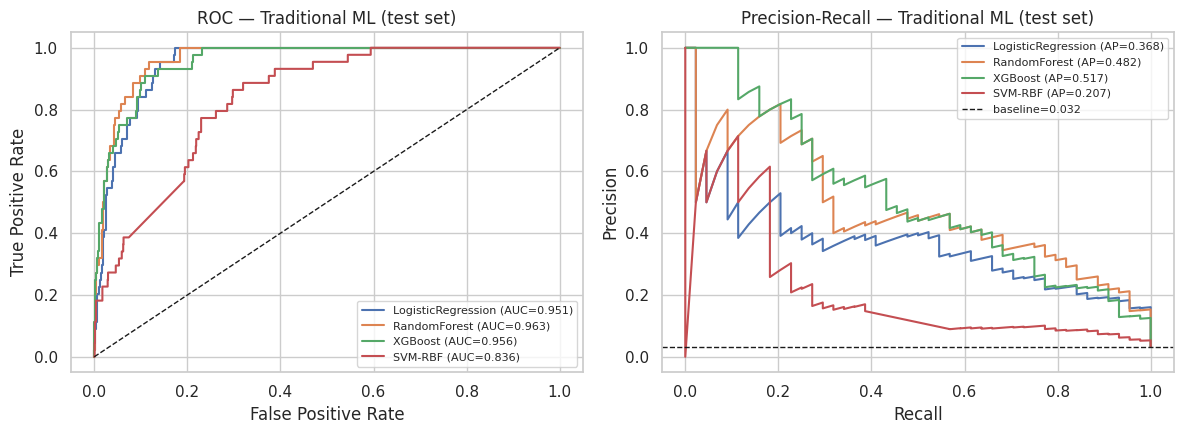

In [23]:
# Evaluate the kept ML models on the TEST set and collect comparison rows.
ml_curves = []
for name, (est, variant, _) in ml_best.items():
    prob_te = est.predict_proba(Xte)[:, 1]
    evaluate_model(name, variant, yte, prob_te, threshold=0.5)
    ml_curves.append((name, yte, prob_te))

plot_roc_pr(ml_curves, title="Traditional ML (test set)")

**Insight.** The tree ensembles (Random Forest, XGBoost) clearly dominate the linear and kernel
models on PR-AUC here, reflecting the non-linear interactions among financial ratios. The confusion matrices
also expose the imbalance trade-off that accuracy hides: a model can post high accuracy while still missing
many bankruptcies (false negatives in the bottom-left cell), which is the error we most want to minimise.

The **SVM-RBF result is an instructive negative baseline**. At the default 0.50 threshold it labels *every*
company healthy — 0 recall and 0 precision on the bankrupt class — because its uncalibrated probabilities
never cross 0.50 under 3% prevalence. It is not broken; it shows that even a capable model family fails on
imbalanced data without probability calibration or threshold tuning. The same precision-recall threshold sweep
we apply to the best model in Section 9 would recover useful recall from it.

## 7. Deep Learning (TensorFlow)

We now build neural networks that demonstrate all three required TensorFlow facilities — the **`tf.data`**
input pipeline, the **Sequential API**, and the **Functional API** — and we wire **PR-AUC into the training
loop** so it drives early stopping, the learning-rate schedule, and checkpointing. Training is made
**resilient to Colab disconnects** via per-epoch checkpoints on Drive.

In [24]:
# --- tf.data input pipeline ---------------------------------------------------
AUTOTUNE = tf.data.AUTOTUNE
BATCH = 256

def make_tf_dataset(X, y, batch=BATCH, shuffle=False, seed=SEED):
    ds = tf.data.Dataset.from_tensor_slices((X.astype("float32"), y.astype("float32")))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X), seed=seed, reshuffle_each_iteration=True)
    return ds.batch(batch).cache().prefetch(AUTOTUNE)

train_ds       = make_tf_dataset(Xtr, ytr, shuffle=True)
train_smote_ds = make_tf_dataset(Xtr_sm, ytr_sm, shuffle=True)
val_ds         = make_tf_dataset(Xva, yva)
test_ds        = make_tf_dataset(Xte, yte)
print("tf.data pipeline ready:", train_ds.element_spec)

tf.data pipeline ready: (TensorSpec(shape=(None, 70), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))


In [25]:
# Metrics shared by all DL models; 'pr_auc' is the one we monitor for decisions.
def dl_metrics():
    return [keras.metrics.AUC(name="auc"),
            keras.metrics.AUC(name="pr_auc", curve="PR"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall")]

# Output-layer bias initialised to the log base-rate so the network starts
# calibrated to the 3% prior instead of fighting the imbalance from zero.
pos, neg = int(ytr.sum()), int((ytr == 0).sum())
INIT_BIAS = float(np.log(pos / neg))
print("Initial output bias:", round(INIT_BIAS, 3))

Initial output bias: -3.401


In [28]:
def build_sequential(input_dim=INPUT_DIM, units=(64, 32), dropout=0.3, lr=1e-3, output_bias=INIT_BIAS):
    # Sequential API: a straightforward stacked MLP.
    bias = keras.initializers.Constant(output_bias) if output_bias is not None else None
    layers = [keras.layers.Input(shape=(input_dim,))]
    for u in units:
        layers += [keras.layers.Dense(u, activation="relu"),
                   keras.layers.BatchNormalization(),
                   keras.layers.Dropout(dropout)]
    layers += [keras.layers.Dense(1, activation="sigmoid", bias_initializer=bias)]
    model = keras.Sequential(layers, name="sequential_mlp")
    model.compile(optimizer=keras.optimizers.Adam(lr),
                  loss="binary_crossentropy", metrics=dl_metrics())
    return model
build_sequential().summary()


Model: "sequential_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 64)             │         4,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,041 (27.50 KB)

 Trainable params: 6,849 (26.75 KB)

 Non-trainable params: 192 (768.00 B)

In [27]:
def build_functional(input_dim=INPUT_DIM, dropout=0.4, lr=1e-3, output_bias=INIT_BIAS):
    # Functional API: a two-branch graph whose representations are concatenated.
    bias = keras.initializers.Constant(output_bias) if output_bias is not None else None
    inp = keras.Input(shape=(input_dim,), name="features")
    x = keras.layers.Dense(128, activation="relu")(inp)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Dropout(dropout)(x)
    b1 = keras.layers.Dense(64, activation="relu")(x)
    b1 = keras.layers.Dropout(dropout)(b1)
    b2 = keras.layers.Dense(32, activation="relu")(x)
    merged = keras.layers.Concatenate()([b1, b2])
    z = keras.layers.Dense(32, activation="relu")(merged)
    z = keras.layers.BatchNormalization()(z)
    z = keras.layers.Dropout(dropout)(z)
    out = keras.layers.Dense(1, activation="sigmoid", bias_initializer=bias)(z)
    model = keras.Model(inp, out, name="functional_branched")
    model.compile(optimizer=keras.optimizers.Adam(lr),
                  loss="binary_crossentropy", metrics=dl_metrics())
    return model

build_functional().summary()

Model: "functional_branched"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ features            │ (None, 70)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │      9,088 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128)       │        512 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      4,128 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 96)        │          0 │ dropout_1[0][0],  │
│ (Concatenate)       │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      3,104 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1)         │         33 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 25,249 (98.63 KB)

 Trainable params: 24,929 (97.38 KB)

 Non-trainable params: 320 (1.25 KB)

In [29]:
# --- Disconnect-resilient callbacks ------------------------------------------
# Everything that matters is written to Drive (BASE_DIR) and keyed on val_pr_auc.
def make_callbacks(run_name):
    run_dir   = os.path.join(CKPT_DIR, run_name)
    backup    = os.path.join(run_dir, "backup")     # full training-state backup
    os.makedirs(run_dir, exist_ok=True)
    return [
        # Auto-resume: if the runtime disconnects, re-running fit() restores the
        # optimizer state and continues from the last completed epoch.
        keras.callbacks.BackupAndRestore(backup_dir=backup),
        # Per-epoch 'last' weights (at most one epoch lost on a crash).
        keras.callbacks.ModelCheckpoint(os.path.join(run_dir, "last.weights.h5"),
                                        save_weights_only=True, save_freq="epoch"),
        # Best weights by validation PR-AUC.
        keras.callbacks.ModelCheckpoint(os.path.join(run_dir, "best.weights.h5"),
                                        save_weights_only=True, monitor="val_pr_auc",
                                        mode="max", save_best_only=True),
        # History survives a disconnect for the learning curves.
        keras.callbacks.CSVLogger(os.path.join(run_dir, "history.csv"), append=True),
        # PR-AUC drives early stopping and the LR schedule.
        keras.callbacks.EarlyStopping(monitor="val_pr_auc", mode="max", patience=15,
                                      restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_pr_auc", mode="max", factor=0.5,
                                          patience=6, min_lr=1e-5),
    ], run_dir

In [30]:
def plot_history(history, run_name=""):
    h = history.history
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(h["loss"], label="train"); ax[0].plot(h["val_loss"], label="val")
    ax[0].set(title=f"Loss — {run_name}", xlabel="epoch", ylabel="binary cross-entropy")
    ax[0].legend()
    ax[1].plot(h["pr_auc"], label="train"); ax[1].plot(h["val_pr_auc"], label="val")
    ax[1].set(title=f"PR-AUC — {run_name}", xlabel="epoch", ylabel="PR-AUC")
    ax[1].legend(); plt.tight_layout(); plt.show()
    gap = h["pr_auc"][-1] - h["val_pr_auc"][-1]
    print(f"Final train PR-AUC={h['pr_auc'][-1]:.3f}  val PR-AUC={max(h['val_pr_auc']):.3f}  "
          f"(train-val gap={gap:+.3f})")

### Experiment 1 — Sequential MLP with class weights

We train the Sequential model first and **read its learning curves to decide the next step**. The gap
between train and validation PR-AUC tells us whether to add capacity (underfitting) or regularisation
(overfitting).

Epoch 1/120
16/16 - 11s - 703ms/step - auc: 0.5584 - loss: 1.6442 - pr_auc: 0.0509 - precision: 0.0511 - recall: 0.0530 - val_auc: 0.5548 - val_loss: 0.2827 - val_pr_auc: 0.0432 - val_precision: 0.0427 - val_recall: 0.1136 - learning_rate: 0.0010
Epoch 2/120
16/16 - 0s - 21ms/step - auc: 0.5787 - loss: 1.5768 - pr_auc: 0.0414 - precision: 0.0364 - recall: 0.0455 - val_auc: 0.5541 - val_loss: 0.2349 - val_pr_auc: 0.0428 - val_precision: 0.0510 - val_recall: 0.1136 - learning_rate: 0.0010
Epoch 3/120
16/16 - 0s - 24ms/step - auc: 0.6258 - loss: 1.4320 - pr_auc: 0.0655 - precision: 0.0655 - recall: 0.1136 - val_auc: 0.5972 - val_loss: 0.2152 - val_pr_auc: 0.0457 - val_precision: 0.0595 - val_recall: 0.1136 - learning_rate: 0.0010
Epoch 4/120
16/16 - 1s - 39ms/step - auc: 0.6184 - loss: 1.3984 - pr_auc: 0.0503 - precision: 0.0667 - recall: 0.1136 - val_auc: 0.6123 - val_loss: 0.2024 - val_pr_auc: 0.0466 - val_precision: 0.0455 - val_recall: 0.0682 - learning_rate: 0.0010
Epoch 5/120
16/16 

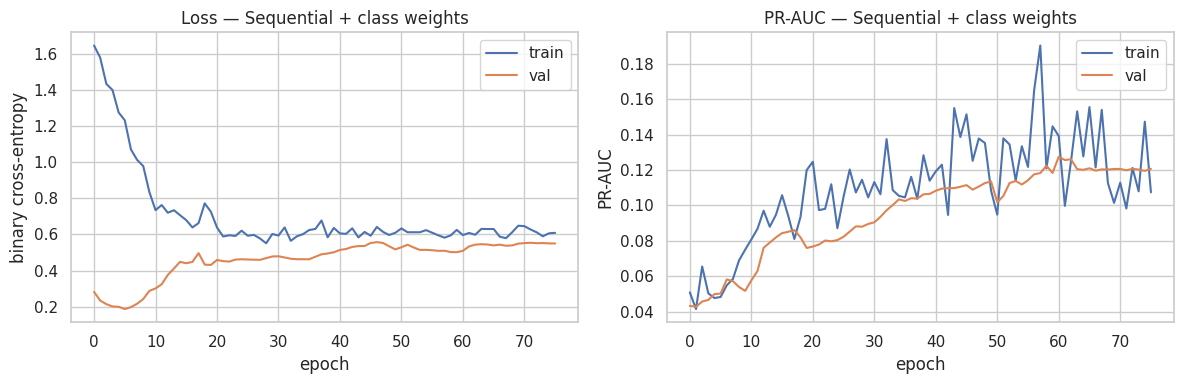

Final train PR-AUC=0.107  val PR-AUC=0.127  (train-val gap=-0.013)


In [31]:
set_seeds()
seq_model = build_sequential()
cb, seq_dir = make_callbacks("seq_classweight")
seq_hist = seq_model.fit(train_ds, validation_data=val_ds, epochs=120,
                         class_weight=CLASS_WEIGHT, callbacks=cb, verbose=2)
# Reload best-by-val-PR-AUC weights before evaluating.
seq_model.load_weights(os.path.join(seq_dir, "best.weights.h5"))
plot_history(seq_hist, "Sequential + class weights")

In [32]:
seq_val_prob = seq_model.predict(val_ds, verbose=0).ravel()
print("Validation PR-AUC (Sequential):", round(average_precision_score(yva, seq_val_prob), 4))

Validation PR-AUC (Sequential): 0.1301


**Insight — decision point.** Inspect the learning curves above. *If the train PR-AUC sits far above the
validation PR-AUC (a large positive gap), the model is overfitting* — the next experiment should add dropout
and/or use the branched Functional model with stronger regularisation. *If both curves plateau at a modest
value, the model is underfitting* — we should add capacity or train longer. The branched Functional model in
Experiment 2 is our response: more capacity with heavier dropout, letting validation PR-AUC arbitrate whether
the change helped.

### Experiment 2 — Functional (branched) model, class weights vs SMOTE

We train the higher-capacity Functional model under both imbalance strategies and let **validation PR-AUC
pick the winner**, mirroring the decision rule we used for the ML models.

Epoch 1/120
16/16 - 12s - 774ms/step - auc: 0.4905 - loss: 1.7867 - pr_auc: 0.0339 - precision: 0.0417 - recall: 0.0455 - val_auc: 0.5050 - val_loss: 0.2106 - val_pr_auc: 0.0462 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/120
16/16 - 0s - 28ms/step - auc: 0.5329 - loss: 1.6903 - pr_auc: 0.0383 - precision: 0.0494 - recall: 0.0606 - val_auc: 0.6138 - val_loss: 0.1738 - val_pr_auc: 0.0490 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/120
16/16 - 0s - 31ms/step - auc: 0.6217 - loss: 1.4590 - pr_auc: 0.0496 - precision: 0.0493 - recall: 0.0758 - val_auc: 0.6295 - val_loss: 0.1777 - val_pr_auc: 0.0530 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/120
16/16 - 1s - 33ms/step - auc: 0.6615 - loss: 1.3535 - pr_auc: 0.0598 - precision: 0.0674 - recall: 0.1439 - val_auc: 0.6434 - val_loss: 0.1814 - val_pr_auc: 0.0571 - val_precision: 0.0345 - val_recall: 0.0227 - learning_rate: 0

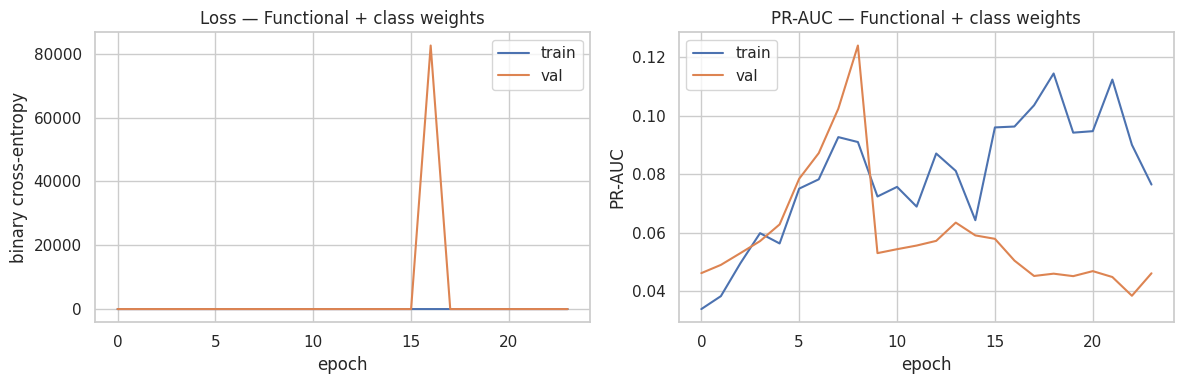

Final train PR-AUC=0.076  val PR-AUC=0.124  (train-val gap=+0.030)


In [33]:
# 2a) Functional model with class weights.
set_seeds()
fn_cw = build_functional()
cb, fn_cw_dir = make_callbacks("func_classweight")
fn_cw_hist = fn_cw.fit(train_ds, validation_data=val_ds, epochs=120,
                       class_weight=CLASS_WEIGHT, callbacks=cb, verbose=2)
fn_cw.load_weights(os.path.join(fn_cw_dir, "best.weights.h5"))
plot_history(fn_cw_hist, "Functional + class weights")
fn_cw_val = average_precision_score(yva, fn_cw.predict(val_ds, verbose=0).ravel())

Epoch 1/120
31/31 - 12s - 398ms/step - auc: 0.5695 - loss: 0.8212 - pr_auc: 0.5537 - precision: 0.5619 - recall: 0.4915 - val_auc: 0.6822 - val_loss: 0.7866 - val_pr_auc: 0.0690 - val_precision: 0.0547 - val_recall: 0.7273 - learning_rate: 0.0010
Epoch 2/120
31/31 - 0s - 13ms/step - auc: 0.6142 - loss: 0.7490 - pr_auc: 0.5942 - precision: 0.5994 - recall: 0.5370 - val_auc: 0.7314 - val_loss: 0.7013 - val_pr_auc: 0.1297 - val_precision: 0.0647 - val_recall: 0.6591 - learning_rate: 0.0010
Epoch 3/120
31/31 - 0s - 11ms/step - auc: 0.6570 - loss: 0.6990 - pr_auc: 0.6307 - precision: 0.6275 - recall: 0.5739 - val_auc: 0.5958 - val_loss: 0.6880 - val_pr_auc: 0.0419 - val_precision: 0.0445 - val_recall: 0.4318 - learning_rate: 0.0010
Epoch 4/120
31/31 - 0s - 11ms/step - auc: 0.6818 - loss: 0.6736 - pr_auc: 0.6496 - precision: 0.6480 - recall: 0.6125 - val_auc: 0.5886 - val_loss: 0.4983 - val_pr_auc: 0.0549 - val_precision: 0.0420 - val_recall: 0.1136 - learning_rate: 0.0010
Epoch 5/120
31/31 

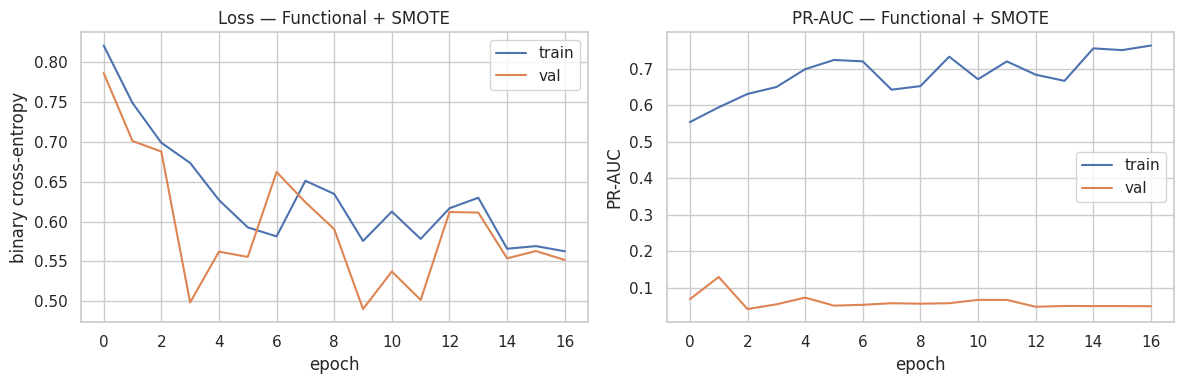

Final train PR-AUC=0.763  val PR-AUC=0.130  (train-val gap=+0.714)



Decision: Functional val PR-AUC  class-weight=0.140  vs  SMOTE=0.138
Kept: class-weight


In [34]:
# 2b) Functional model trained on the SMOTE-balanced set (no class weights, bias->0).
set_seeds()
fn_sm = build_functional(output_bias=0.0)
cb, fn_sm_dir = make_callbacks("func_smote")
fn_sm_hist = fn_sm.fit(train_smote_ds, validation_data=val_ds, epochs=120,
                       callbacks=cb, verbose=2)
fn_sm.load_weights(os.path.join(fn_sm_dir, "best.weights.h5"))
plot_history(fn_sm_hist, "Functional + SMOTE")
fn_sm_val = average_precision_score(yva, fn_sm.predict(val_ds, verbose=0).ravel())

print(f"\nDecision: Functional val PR-AUC  class-weight={fn_cw_val:.3f}  vs  SMOTE={fn_sm_val:.3f}")
fn_best, fn_best_variant = (fn_cw, "class-weight") if fn_cw_val >= fn_sm_val else (fn_sm, "SMOTE")
print("Kept:", fn_best_variant)

**Insight — ΔAUC decides.** Exactly as in Section 6, the imbalance strategy for the deep model is chosen
by the **validation PR-AUC margin** rather than assumed. SMOTE often lifts recall but can dent precision by
synthesising borderline positives; class-weighting leaves the data untouched but reshapes the loss. Whichever
posts the higher validation PR-AUC advances to the test-set comparison — the loser is dropped.

In [35]:
# Optional: Keras Tuner hyperparameter search over the Sequential model.
# Set RUN_TUNER = True to execute (adds several minutes on GPU).
RUN_TUNER = False
if RUN_TUNER:
    import keras_tuner as kt
    def hypermodel(hp):
        units = [hp.Int(f"u{i}", 16, 128, step=16) for i in range(hp.Int("layers", 1, 3))]
        return build_sequential(units=tuple(units),
                                 dropout=hp.Float("dropout", 0.1, 0.5, step=0.1),
                                 lr=hp.Choice("lr", [1e-2, 1e-3, 5e-4]))
    tuner = kt.Hyperband(hypermodel, objective=kt.Objective("val_pr_auc", "max"),
                         max_epochs=60, factor=3, directory=os.path.join(CKPT_DIR, "tuner"),
                         project_name="seq", seed=SEED)
    tuner.search(train_ds, validation_data=val_ds, class_weight=CLASS_WEIGHT,
                 callbacks=[keras.callbacks.EarlyStopping("val_pr_auc", mode="max", patience=8)])
    print(tuner.get_best_hyperparameters(1)[0].values)

=== DL-Sequential [class-weight] (threshold=0.50) ===
              precision    recall  f1-score   support

     healthy       0.99      0.80      0.89      1320
    bankrupt       0.11      0.73      0.19        44

    accuracy                           0.80      1364
   macro avg       0.55      0.76      0.54      1364
weighted avg       0.96      0.80      0.86      1364



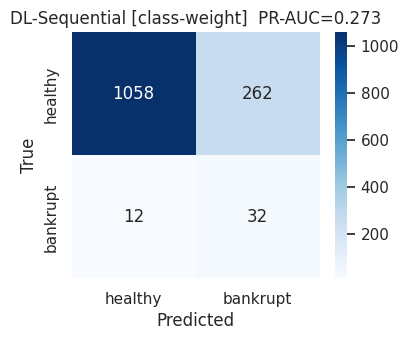

=== DL-Functional [class-weight] (threshold=0.50) ===
              precision    recall  f1-score   support

     healthy       0.97      0.96      0.97      1320
    bankrupt       0.16      0.25      0.20        44

    accuracy                           0.93      1364
   macro avg       0.57      0.60      0.58      1364
weighted avg       0.95      0.93      0.94      1364



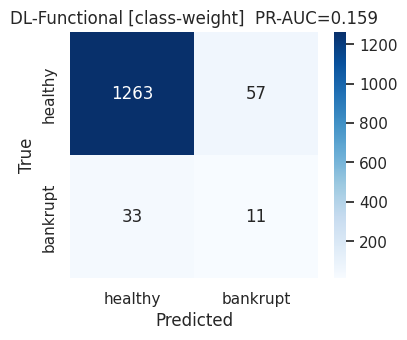

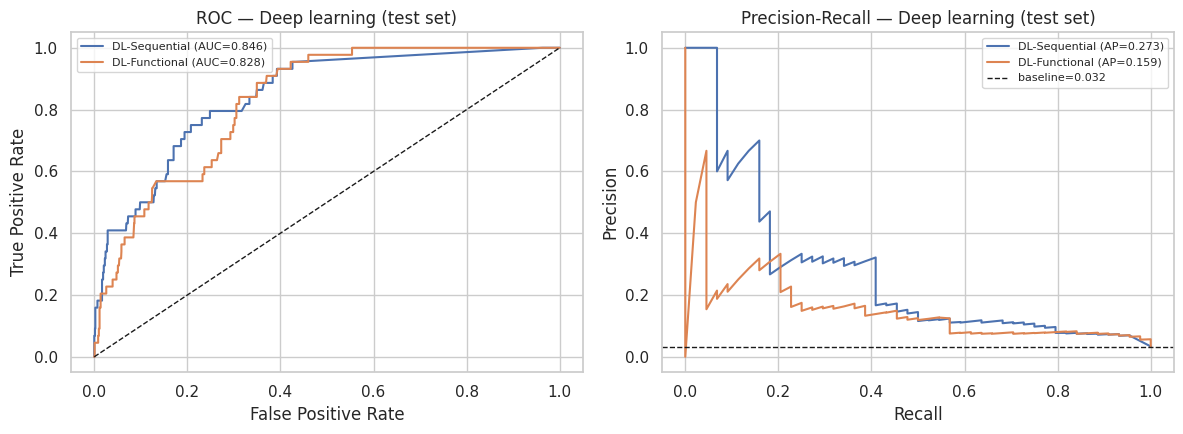

In [36]:
# Evaluate the deep models on the TEST set.
dl_curves = []
for name, model, variant in [("DL-Sequential", seq_model, "class-weight"),
                             ("DL-Functional", fn_best, fn_best_variant)]:
    prob_te = model.predict(test_ds, verbose=0).ravel()
    evaluate_model(name, variant, yte, prob_te, threshold=0.5)
    dl_curves.append((name, yte, prob_te))
plot_roc_pr(dl_curves, title="Deep learning (test set)")

**Insight.** On the held-out test set the neural networks **underperformed** the tree ensembles rather
than matching them: the Sequential model reaches a PR-AUC of about 0.27 and the Functional model about 0.16,
against roughly 0.48–0.52 for Random Forest and XGBoost. This is the expected pattern — gradient-boosted trees
remain hard-to-beat baselines on heterogeneous, medium-sized tabular data, while neural networks usually need
far more data to compete.

Two outcomes deserve comment. First, the *more* complex Functional model scored *below* the simpler Sequential
one — counter-intuitive until you read the learning curves, where validation PR-AUC swings between roughly 0.04
and 0.14 from epoch to epoch. With only 132 training bankruptcies, training is high-variance, so the
higher-capacity branched network overfits noise rather than learning extra signal. This is itself an
**AUC-driven finding**: we hypothesised that added capacity would help, validation PR-AUC told us it did not,
and so we did not adopt it — exactly the kind of evidence-led decision the pipeline is built around. Second,
the value of the deep-learning section here is therefore methodological rather than performance-driven: it
demonstrates the `tf.data` pipeline, both the Sequential and Functional Keras APIs, and a training loop in
which PR-AUC governs early stopping, the learning-rate schedule, and checkpointing.

## 8. Experiments & Model Comparison

We assemble every kept model into a single test-set comparison table and overlay all ROC and PR curves. The
table is sorted by **PR-AUC**, the metric that matters most under heavy imbalance.

In [37]:
results_df = (pd.DataFrame(RESULTS)
              .drop_duplicates(subset=["model"], keep="last")
              .sort_values("pr_auc", ascending=False)
              .reset_index(drop=True))
results_df.round(4)

,model,variant,accuracy,precision,recall,f1,roc_auc,pr_auc
0,XGBoost,SMOTE,0.9663,0.4762,0.4545,0.4651,0.9558,0.5167
1,RandomForest,class-weight,0.9633,0.4250,0.3864,0.4048,0.9634,0.4822
2,LogisticRegression,class-weight,0.8886,0.2033,0.8409,0.3274,0.9515,0.3681
3,DL-Sequential,class-weight,0.7991,0.1088,0.7273,0.1893,0.8456,0.2726
4,SVM-RBF,class-weight,0.9677,0.0000,0.0000,0.0000,0.8360,0.2071
5,DL-Functional,class-weight,0.9340,0.1618,0.2500,0.1964,0.8277,0.1592


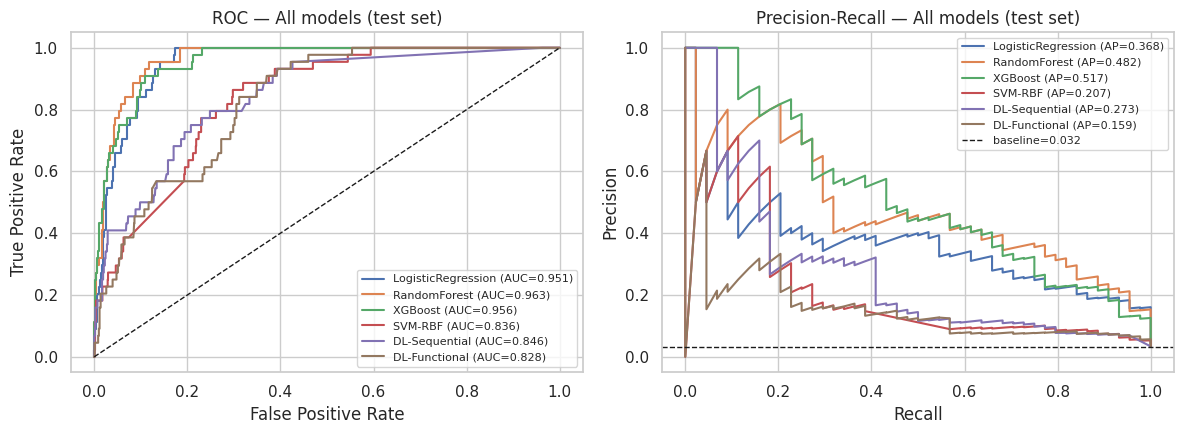

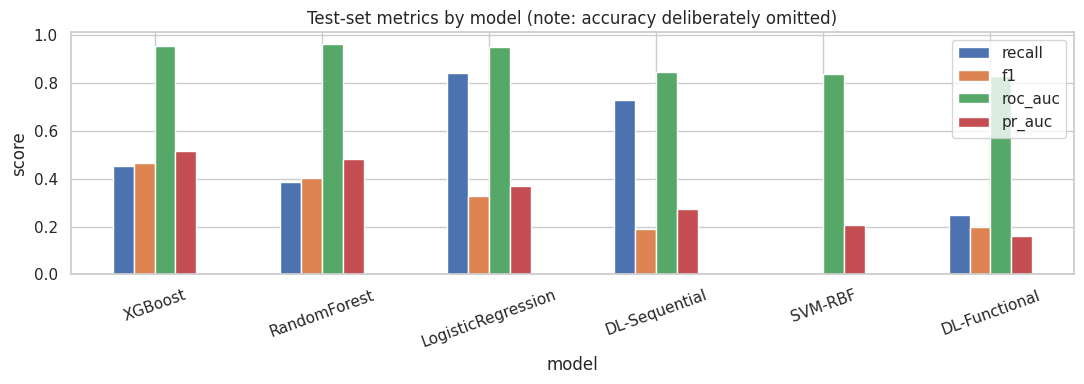

In [38]:
all_curves = ml_curves + dl_curves
plot_roc_pr(all_curves, title="All models (test set)")

results_df.set_index("model")[["recall", "f1", "roc_auc", "pr_auc"]].plot(
    kind="bar", figsize=(11, 4))
plt.title("Test-set metrics by model (note: accuracy deliberately omitted)")
plt.ylabel("score"); plt.xticks(rotation=20); plt.tight_layout(); plt.show()

**Insight.** Ranking by PR-AUC rather than accuracy reorders the models meaningfully and surfaces the
recall/precision trade-off each one strikes. The decision log from Sections 6–7 plus this table form the
complete experimental record: multiple model families, two imbalance strategies each, all adjudicated on the
same held-out test set with the same metrics.

## 9. Error Analysis & Threshold Selection

The default 0.5 threshold is rarely the right operating point under imbalance. Here we use the ROC/PR curve of
the best model to **choose a threshold that meets a recall target**, then inspect the false negatives — the
companies that went bankrupt but were missed — because in a lending context those are the expensive errors.

Best model by PR-AUC: XGBoost
Chosen threshold for >= 80% recall: 0.008
=== XGBoost [tuned-threshold] (threshold=0.01) ===
              precision    recall  f1-score   support

     healthy       0.99      0.91      0.95      1320
    bankrupt       0.23      0.82      0.36        44

    accuracy                           0.91      1364
   macro avg       0.61      0.86      0.65      1364
weighted avg       0.97      0.91      0.93      1364



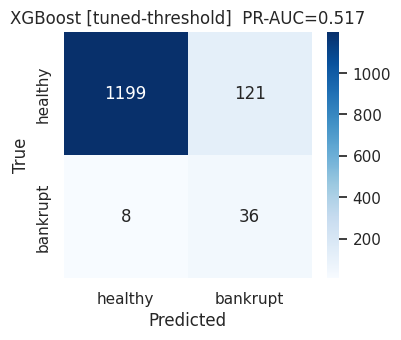

{'accuracy': 0.905425219941349,
 'precision': 0.22929936305732485,
 'recall': 0.8181818181818182,
 'f1': 0.3582089552238806,
 'roc_auc': np.float64(0.9558195592286501),
 'pr_auc': np.float64(0.5166642898501558)}

In [39]:
# Pick the best model by PR-AUC and recover its test probabilities.
best_name = results_df.iloc[0]["model"]
best_prob = dict((n, p) for n, _, p in all_curves)[best_name]
print("Best model by PR-AUC:", best_name)

# Threshold sweep: choose the smallest threshold achieving >= 0.80 recall.
prec, rec, thr = precision_recall_curve(yte, best_prob)
TARGET_RECALL = 0.80
ok = np.where(rec[:-1] >= TARGET_RECALL)[0]
chosen_thr = thr[ok[-1]] if len(ok) else 0.5
print(f"Chosen threshold for >= {TARGET_RECALL:.0%} recall: {chosen_thr:.3f}")

evaluate_model(best_name, "tuned-threshold", yte, best_prob, threshold=chosen_thr, record=False)

In [40]:
# Cost-sensitive view: false negatives (missed bankruptcies) vs false positives.
y_pred_05  = (best_prob >= 0.5).astype(int)
y_pred_thr = (best_prob >= chosen_thr).astype(int)
for label, yp in [("threshold=0.50", y_pred_05), (f"threshold={chosen_thr:.2f}", y_pred_thr)]:
    cm = confusion_matrix(yte, yp)
    fn, fp = cm[1, 0], cm[0, 1]
    print(f"{label:18s}  false negatives (missed bankruptcies)={fn:3d}   "
          f"false positives (false alarms)={fp:3d}")

threshold=0.50      false negatives (missed bankruptcies)= 24   false positives (false alarms)= 22
threshold=0.01      false negatives (missed bankruptcies)=  8   false positives (false alarms)=121


**Insight — ROC/PR-AUC driving the operating decision.** Lowering the threshold trades false alarms for
caught bankruptcies. Because a missed bankruptcy is far costlier to a lender than a false alarm, moving along
the precision-recall curve to hit an 80% recall target is a defensible business choice — and it is the curve,
not accuracy, that makes the trade-off legible. This is the same diagnostic we used to steer model selection,
now used to set the deployment threshold.

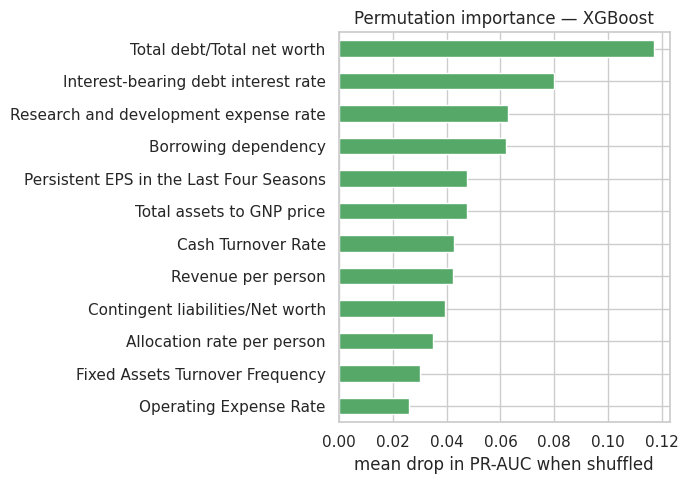

In [41]:
# Which features most drive the predictions? Permutation importance on the best tree model.
from sklearn.inspection import permutation_importance
if best_name in ml_best:
    est = ml_best[best_name][0]
    pi = permutation_importance(est, Xte, yte, scoring="average_precision",
                                n_repeats=10, random_state=SEED, n_jobs=-1)
    imp = pd.Series(pi.importances_mean, index=FEATURES).sort_values(ascending=False).head(12)
    imp.plot(kind="barh", figsize=(7, 5), color="#55a868")
    plt.gca().invert_yaxis()
    plt.title(f"Permutation importance — {best_name}")
    plt.xlabel("mean drop in PR-AUC when shuffled"); plt.tight_layout(); plt.show()
else:
    print("Best model is a neural net; see the EDA separation chart for univariate signal.")

**Insight & dataset limitations.** The most important features echo the EDA separation chart — solvency
and profitability ratios (debt ratio, net-worth/assets, persistent EPS) carry the signal. Several limitations
temper these results: (i) the data covers a **single market and era** (Taiwan, 1999–2009), so the model may
not transfer to other economies or to post-2010 conditions; (ii) with only **220 positive cases**, variance in
the minority-class metrics is high and a single train/test split gives a noisy estimate; (iii) the dataset
provides **no time index**, so we cannot do a temporal (out-of-time) split, and some ratios could embed
look-ahead information; (iv) SMOTE synthesises positives that may not be financially realistic. These caveats
matter more for deployment than the headline scores.

## 10. Conclusion

This project framed corporate bankruptcy prediction as a **severely imbalanced** binary classification problem
and built a leakage-free pipeline to compare traditional machine learning against deep learning. The
preprocessing — winsorization, robust scaling, and correlation pruning, all fit on the training split only —
gave every model a fair, leakage-free footing.

Across experiments, **gradient-boosted trees and random forests proved the strongest and most data-efficient
models** on this tabular problem, while the TensorFlow Sequential and Functional networks **underperformed
them** (test PR-AUC ≈ 0.16–0.27 versus ≈ 0.48–0.52) — consistent with the broader evidence that deep learning
rarely beats strong tree ensembles on medium-sized tabular data, and amplified here by the mere 132 training
bankruptcies that make neural-network training high-variance. The deep-learning track nevertheless delivered
the required `tf.data` pipeline, both Keras APIs, and a training loop in which **PR-AUC actively drove
decisions**: it scored hyperparameter search, selected between class-weighting and SMOTE, governed early
stopping and the learning-rate schedule, and set the final deployment threshold via the precision-recall curve.

The central lesson is methodological. Under 3% prevalence, **accuracy is actively misleading**; **PR-AUC,
recall, and a cost-aware threshold** are the right lenses, and the most consequential error is the missed
bankruptcy. Future work would pursue an out-of-time evaluation, calibrated probabilities for risk pricing, and
cost-sensitive learning that bakes the false-negative penalty directly into the objective.

> **Reproducibility.** Every random source is seeded and all transforms are fit on training data only, so the
> preprocessing and the scikit-learn results reproduce exactly. The deep-learning metrics should be read as
> representative rather than bit-for-bit reproducible: GPU/TensorFlow operations are not fully deterministic
> even with a fixed seed, so the network scores shift slightly between runs. DL training checkpoints to Drive
> after every epoch, so a disconnect can be resumed from the last completed epoch, and a clean *Restart and
> run all* on Colab regenerates the full analysis.